# T32 — Rotating paleomagnetic poles into reconstructed plate frames

**Take a set of paleomagnetic poles defined on different plates, rotate each to a chosen reconstruction time using `gplately`'s rotation model, and over-plot them on a paleo-Earth basemap. A short calculations companion to T27, replacing`frp.get_pole` + `pmag.pt_rot` hand-rolled rotation with the canonical `gplately` operation.**

## What this notebook produces

Rotating a small set of paleomagnetic pole positions from their present-day craton frame into a target-age reconstruction frame is a standard paleomagnetic exercise. The classical approach uses Euler poles from a hard-coded static table, applied one plate at a time, with the rotated poles plotted on a polar orthographic projection.

This notebook does the same thing with `gplately`'s rotation model. The arithmetic is identical — apply the (moving=plate, fixed=anchor) rotation at time t to each pole's lat/lon — but using `gplately.Points.reconstruct(time, return_array=True)` plus an anchored rotation model gives us the ability to swap plate models, swap anchor plates, sweep times, and render with pyGMT in the suite's house style.

The bundled CSV under `data/paleomag/test_poles_assorted.csv` contains five paleomagnetic poles of historical interest from four cratons (Laurentia, Baltica, Gondwana, Australia), each tagged with its host plate id. We reconstruct each into the chosen reconstruction frame and plot on a reconstructed paleo-Earth at the same age.

**Audience**: postgrad.
**Difficulty**: ★★☆.

## Learning objectives

- Set up a `gplately.PlateReconstruction` whose rotation tree is anchored to a chosen plate via `pygplates.RotationModel(..., default_anchor_plate_id=N)`.
- Rotate a set of paleomagnetic poles, each on a different host plate, into the common anchored reference frame at a target time.
- Render the result on a paleo-Earth basemap using pyGMT.

## Prerequisites and runtime

- Plate model: Zahirovic 2022 default.
- Bundled data: `data/paleomag/test_poles_assorted.csv`.
- Python: `gplately`, `pygmt`, `pygplates`, `pandas`.
- Runtime: < 30 s.

In [1]:
# Defensive cwd fix: when Jupyter runs this notebook from Notebooks/, the
# `data/...` relative paths used below would not resolve. Step up to the
# suite root once so every `data/...` literal in the rest of the notebook
# finds its file. Idempotent — only runs if `../data` exists and `./data`
# doesn't.
import os as _os
from pathlib import Path as _Path
if _Path("../data").exists() and not _Path("data").exists():
    _os.chdir("..")

# Cell 1 — imports
import numpy as np, pandas as pd
import gplately, pygmt, pygplates
from plate_model_manager import PlateModelManager
from IPython.display import display, HTML
# Library versions (printed for reproducibility)
try:
    import gplately, pygmt, pygplates
    print(f"gplately {gplately.__version__}  pygmt {pygmt.__version__}  pygplates {pygplates.__version__}")
except Exception as _e:
    print(f"version probe failed: {_e}")


gplately 2.0.0.post19+git.2cce7bb3  pygmt v0.18.0  pygplates 1.0.0


## Configuration — change anchor + reconstruction age here

In [2]:
# === USER CONFIGURATION =====================================================
MODEL_NAME          = "Zahirovic2022"
RECONSTRUCTION_TIME = 100.0
ANCHOR_PLATE_ID     = 0          # 0 = mantle frame; try 701 (Africa) to mimic
POLES_CSV           = "data/paleomag/test_poles_assorted.csv"
# ============================================================================


## 1. Load the pole table

In [3]:
# Cell 2 — load poles
poles = pd.read_csv(POLES_CSV, comment="#")
print(poles)


                 pole_label  pole_lon  pole_lat  age_ma  plate_id
0   Newark Supergroup (NAm)     101.0      62.0   200.0       101
1  Karoo dolerites (Africa)     264.0      72.0   183.0       701
2   Paraná LIP (S. America)      88.0      84.5   132.0       201
3      Deccan Traps (India)     282.0      37.0    65.0       501
4    Mt Eclipse (Australia)     338.0      35.0    62.0       801


## 2. Build an anchored PlateReconstruction

In [4]:
# Cell 3 — anchored reconstruction
pmm   = PlateModelManager()
model = pmm.get_model(MODEL_NAME, data_dir="./gplately_data")
rm_anchored = pygplates.RotationModel(
    model.get_rotation_model(),
    default_anchor_plate_id=ANCHOR_PLATE_ID)
recon = gplately.PlateReconstruction(
    rm_anchored,
    model.get_topologies(),
    model.get_static_polygons())


## 3. Rotate each pole into the anchored frame at the target age

In [5]:
# Cell 4 — rotate poles
# Build a Points object with one entry per pole, using each pole's host plate
rotated_lons, rotated_lats = [], []
for _, row in poles.iterrows():
    pt = gplately.Points(recon, [row['pole_lon']], [row['pole_lat']],
                         plate_id=int(row['plate_id']))
    rlons, rlats = pt.reconstruct(RECONSTRUCTION_TIME, return_array=True)
    rotated_lons.append(float(rlons[0]))
    rotated_lats.append(float(rlats[0]))
poles["rotated_lon"] = rotated_lons
poles["rotated_lat"] = rotated_lats
poles


,pole_label,pole_lon,pole_lat,age_ma,plate_id,rotated_lon,rotated_lat
0,Newark Supergroup (NAm),101.0,62.0,200.0,101,95.954179,62.486256
1,Karoo dolerites (Africa),264.0,72.0,183.0,701,5.057327,77.882113
2,Paraná LIP (S. America),88.0,84.5,132.0,201,34.190897,84.077142
3,Deccan Traps (India),282.0,37.0,65.0,501,102.399783,71.975362
4,Mt Eclipse (Australia),338.0,35.0,62.0,801,-13.320849,58.170185


## 4. Paleo-Earth panel with rotated poles

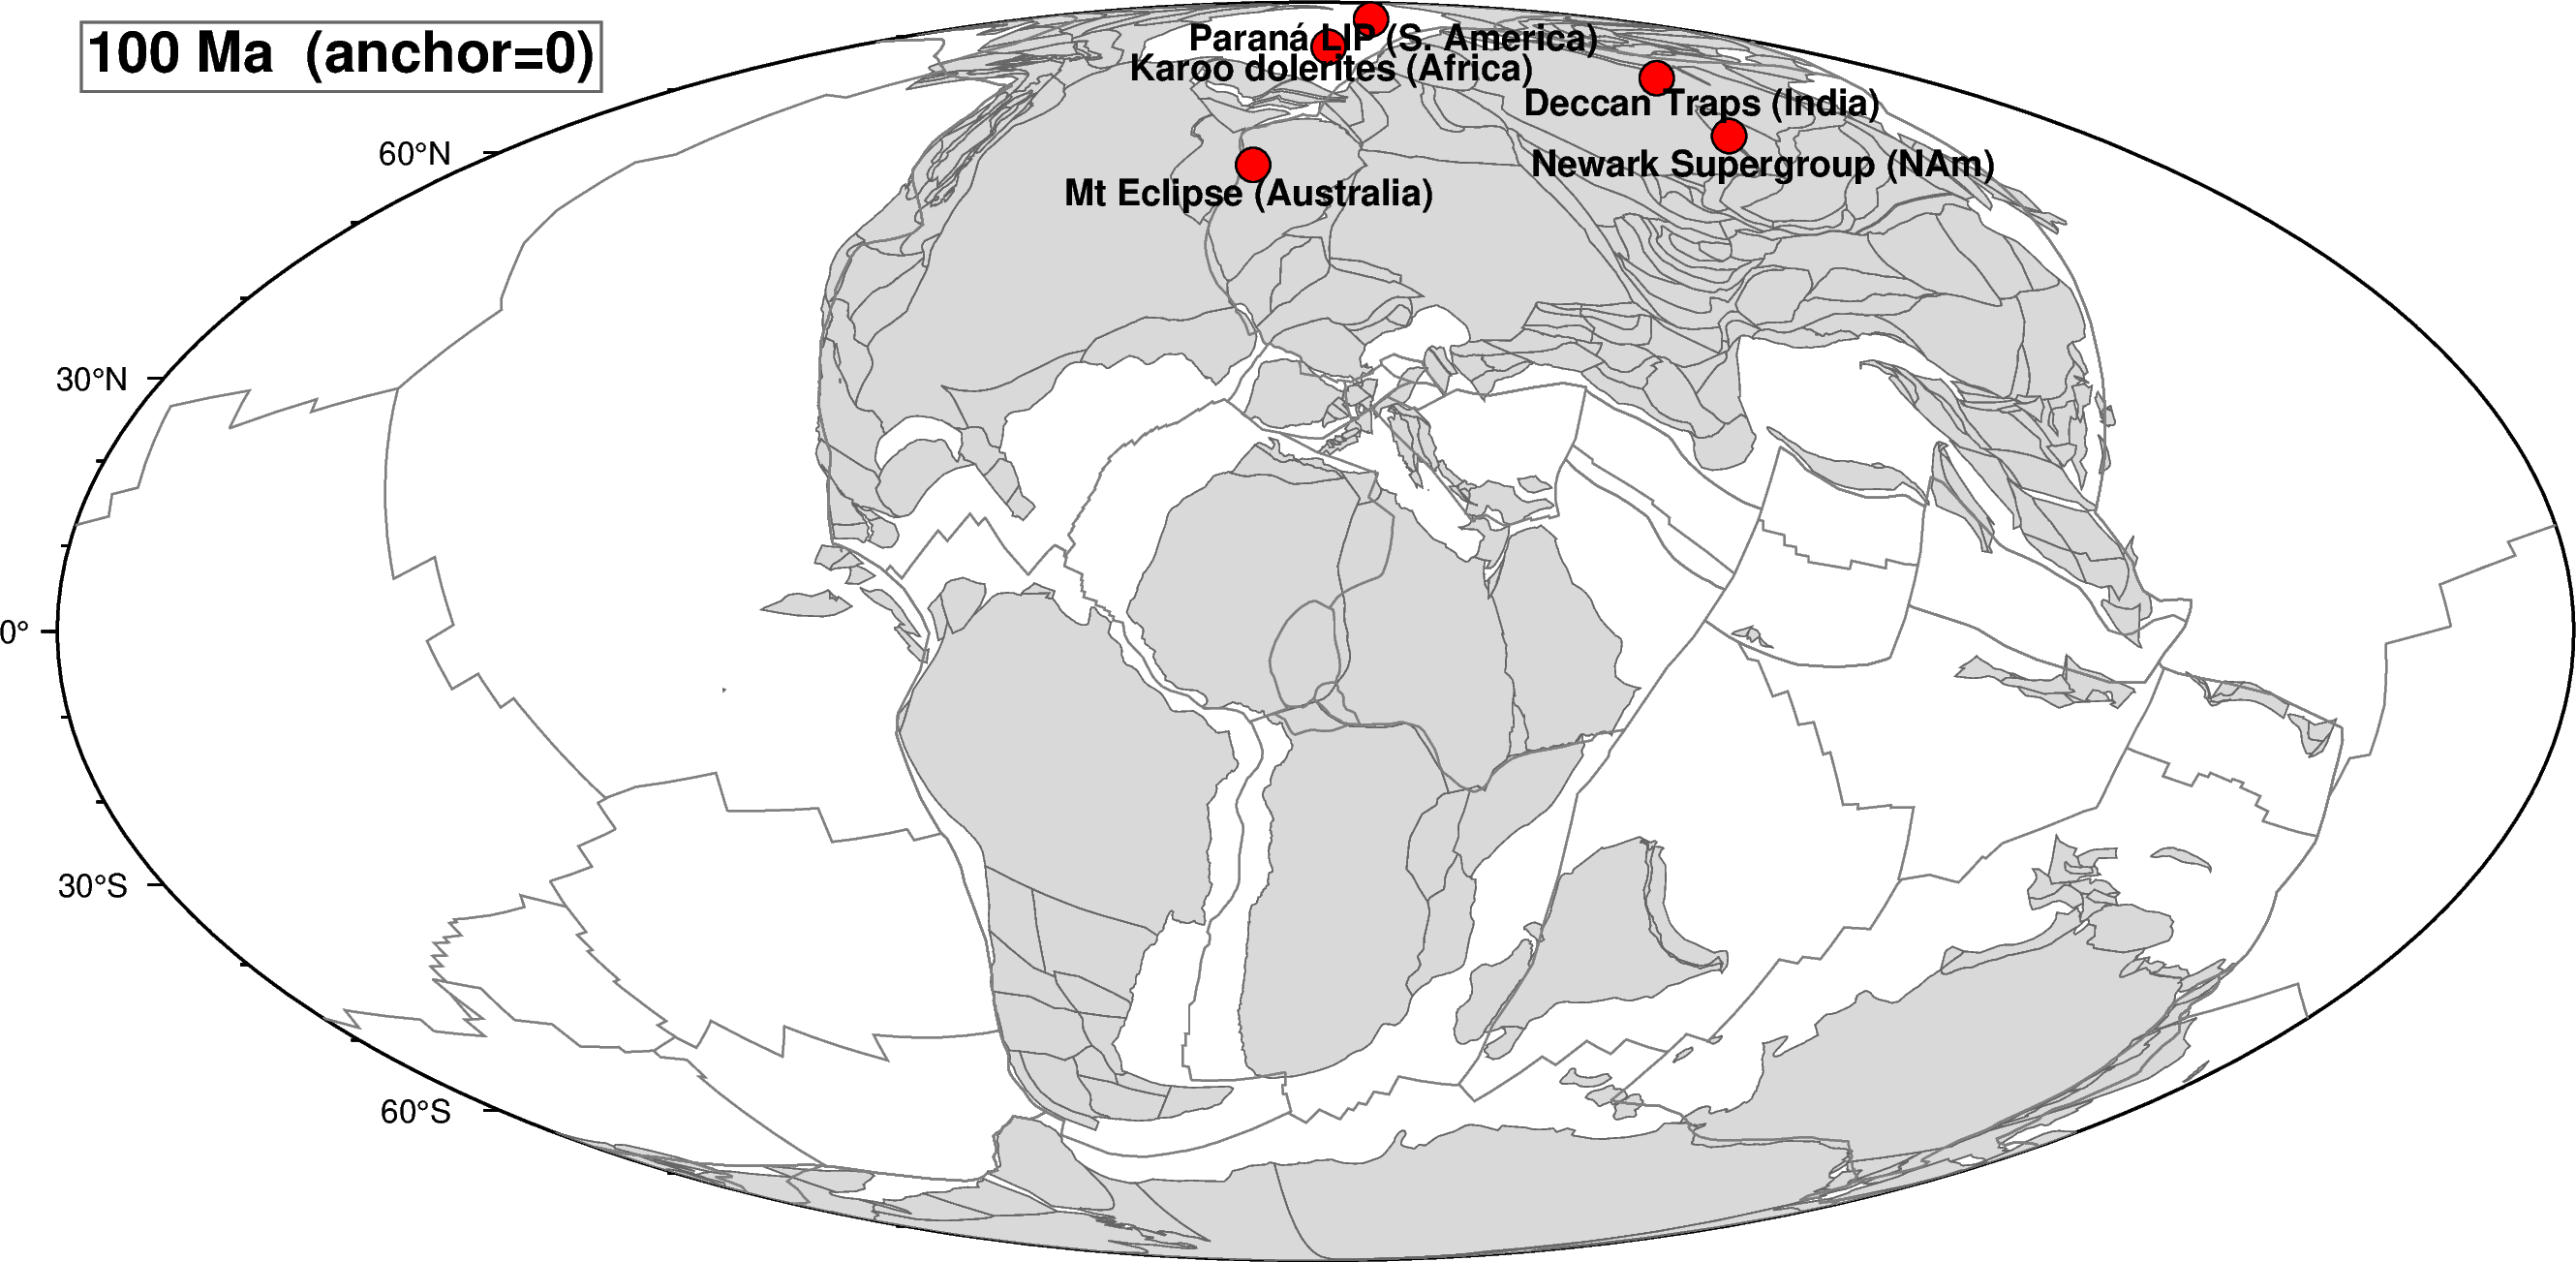

In [6]:
# Cell 5 — render
gplot = gplately.PlotTopologies(
    plate_reconstruction=recon,
    coastlines=model.get_coastlines(),
    continents=model.get_continental_polygons(),
    COBs=model.get_COBs(),
    time=float(RECONSTRUCTION_TIME),

plot_engine=gplately.PygmtPlotEngine(),
)

fig = pygmt.Figure()
fig.basemap(region="d", projection="W0/22c", frame=["af"])
gplot.plot_continents(fig, fill="gray85", pen="0.3p,gray40")
gplot.plot_all_topological_sections(fig, pen="0.5p,gray50")

fig.plot(x=poles["rotated_lon"], y=poles["rotated_lat"],
         style="c0.30c", fill="red", pen="0.5p,black")
for _, row in poles.iterrows():
    fig.text(x=[row["rotated_lon"]], y=[row["rotated_lat"] - 4],
             text=row["pole_label"], font="9p,Helvetica-Bold,black")

fig.text(text=f"{RECONSTRUCTION_TIME:.0f} Ma  (anchor={ANCHOR_PLATE_ID})",
         position="TL", offset="0.25c/-0.25c", justify="TL",
         font="14p,Helvetica-Bold,black",
         fill="white", pen="0.6p,gray40")
fig.show(width=1100)
display(HTML('<div style="height:1cm"></div>'))


## What the figure shows

A polar-frame Mollweide projection at `RECONSTRUCTION_TIME` Ma with the input paleomagnetic poles rotated through the loaded plate model's rotation chain into the target-age reference frame, each labelled by its host plate. The in-frame stamp records the reconstruction age and the anchor plate.

Interpretation:

- **Poles that cluster near the geographic spin axis** (the centre of the projection if you imagine looking down on the pole, or the top of a Mollweide) confirm internal consistency: the rotation model has built each pole's host plate into a configuration that places its paleomag pole at the spin axis at the pole's measurement age.
- **Poles that fall far from the spin axis** indicate model-data residuals — either the rotation model does not exactly fit this pole compilation, or the anchor-plate choice has moved the absolute frame relative to where the poles were defined.

Swapping `ANCHOR_PLATE_ID` between 0 (spin axis) and 701 (Africa) is the classical test for distinguishing absolute-frame differences from plate-relative-motion differences — the relative positions of the poles do not change, but their absolute position rotates as a rigid body.


## Extend this

- **Swap the anchor plate.** Change `ANCHOR_PLATE_ID` from 0 (mantle) to 701 (Africa) or 101 (Laurentia). The poles' rotated positions change but their *relative* configuration on the paleo-Earth does not.
- **Sweep the reconstruction time.** Loop over 0–300 Ma in 25 Ma steps and animate the pole positions converging on the paleomagnetic north pole as t → 0.
- **Cross-reference T27 + T29.** T27 reconstructs continent outlines; this notebook reconstructs points. The arithmetic is identical — the only difference is whether the geometry is a polygon or a point. T29 uses the same point-reconstruction operation for a single paleomagnetic site.

## References

- Mather, B.R. et al. (2024). *Geoscience Data Journal* 11, 3–10.
- Tauxe, L. et al. (2016). *Geochem. Geophys. Geosys.* 17, 2450–2463.
- Zahirovic, S. et al. (2022). *Geoscience Data Journal*.
- Tian, D., Uieda, L., Leong, W.J., Fröhlich, Y., Schlitzer, W., Grund, M., Jones, M., Toney, L., Yao, J., Magen, Y., Tong, J.-H., Ngo, L., Materna, K., Belem, A., Newton, T., Anant, A., Ziebarth, M., Quinn, J. & Wessel, P. (2024). PyGMT: A Python interface for the Generic Mapping Tools. *Zenodo*. https://doi.org/10.5281/zenodo.13679420
- Wessel, P., Luis, J.F., Uieda, L., Scharroo, R., Wobbe, F., Smith, W.H.F. & Tian, D. (2019). The Generic Mapping Tools version 6. *Geochemistry, Geophysics, Geosystems* 20(11), 5556–5564. https://doi.org/10.1029/2019GC008515

